In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

my_ID = 2290
np.random.seed(my_ID)
np.set_printoptions(precision=2)# reduced display precision on numpy arrays

In [49]:
data_train = pd.read_csv('fashion-mnist_train.csv')
data_test = pd.read_csv('fashion-mnist_test.csv')

In [ ]:
# create training and validation set
x_train = data_train.iloc[:, 1:].to_numpy()
t_train = data_train.iloc[:,0].to_numpy()
x_train, x_valid, t_train, t_valid = train_test_split(x_train, t_train, test_size=0.2, random_state=my_ID)
x_train = x_train / 255
x_valid = x_valid / 255
print(f"x_train Shape: {x_train.shape}, x_train Type:{type(x_train)})")
print(f"x_valid Shape: {t_valid.shape}, x_valid Type:{type(t_valid)})")

# create test set
x_test = data_test.iloc[:, 1:].to_numpy()
t_test = data_test.iloc[:,0].to_numpy()
x_test = x_test / 255
print(f"x_test Shape: {x_test.shape}, x_test Type:{type(x_test)})")

x_train Shape: (48000, 784), x_train Type:<class 'numpy.ndarray'>)
x_valid Shape: (12000,), x_valid Type:<class 'numpy.ndarray'>)
x_test Shape: (10000, 784), x_test Type:<class 'numpy.ndarray'>)


Small sample data from data_banknote_authentication.txt


In [2]:
sc = StandardScaler()

dataset = pd.read_csv(
    "data_banknote_authentication.txt",
    header=None)
X_data = dataset.iloc[:, :-1].values
train = dataset.iloc[:, -1].values

rand_seed = 20

# split into train, test and validation set and standardize
X_train, X_test, t_train, t_test = train_test_split(X_data, train, test_size=0.2, random_state=rand_seed)
X_train, X_valid, t_train, t_valid = train_test_split(X_train, t_train, test_size=0.25, random_state=rand_seed)
X_train = sc.fit_transform(X_train)
X_valid = sc.transform(X_valid)
X_test = sc.transform(X_test)

In [56]:
# some convenient code
def l_ce(t, y_pred):
    y_pred[y_pred == 1] = 0.99999999999999999
    y_pred[y_pred == 0] = 0.00000000000000001
    return np.dot(-1 * t, np.log(y_pred)) - np.dot((1 - t), np.log(1 - y_pred))

def sigmoid(z):
    return (1/ (1 + np.exp(-z)))

def relu(h):
    h[h < 0] = 0
    return h


def d_relu(g):
    # relu derivative
    g[g >= 0] = 1
    g[g < 0] = 0
    return g


def new_w(w, w_J):
    alpha = 0.005
    w_new = w - np.dot(alpha, w_J)
    return w_new

def hidden_fwd_relu(W,h):
    z = np.dot(W, np.c_[1, h.T].T)
    # print("z2: {0}\n".format(z2))
    h = relu(z.copy())
    # print("h2: {0}\n".format(h2))
    return h

def hidden_bwd_relu(W,z,h,z_J):
    w_J = np.dot(z_J, np.c_[1, h.T])
    # print("w2_J: {0}\n".format(w2_J))
    z_J = np.multiply(d_relu(z), np.dot(W[:, 1:].T, z_J))
    # print("z1_J: {0}\n".format(z1_J))
    return w_J, z_J

def _neural_net_GD(x, t, W1, W2, W3):
    # fwd
    z1 = np.dot(W1, np.r_[1, x.T][:, None])
    # print("z1: {0}\n".format(z1))
    h1 = relu(z1.copy())
    # print("h1: {0}\n".format(h1))

    z2 = np.dot(W2, np.c_[1, h1.T].T)
    # print("z2: {0}\n".format(z2))
    h2 = relu(z2.copy())
    # print("h2: {0}\n".format(h2))

    z3 = np.dot(W3, np.c_[1, h2.T].T)
    # print("z3: {0}\n".format(z3))
    y = 1 / (1 + np.exp(-z3))
    # print("y: {0}\n".format(y))

    # bwd
    dj_dz3 = -t + y  # cross-entropy loss
    # print("dj_dz3: {0}\n".format(dj_dz3))
    w3_J = dj_dz3 * np.c_[1, h2.T]
    # print("w3_J: {0}\n".format(w3_J))
    z2_J = np.multiply(d_relu(z2), W3[:, 1:].T * dj_dz3)  # element wise multiplication
    # print("z2_J: {0}\n".format(z2_J))

    w2_J = np.dot(z2_J, np.c_[1, h1.T])
    # print("w2_J: {0}\n".format(w2_J))
    z1_J = np.multiply(d_relu(z1), np.dot(W2[:, 1:].T, z2_J))
    # print("z1_J: {0}\n".format(z1_J))
    
    w1_J = np.dot(z1_J, np.r_[1, x.T][None, :])
    # print("w1_J: {0}\n".format(w1_J))

    # new weights
    W1_new = new_w(W1, w1_J)
    W2_new = new_w(W2, w2_J)
    W3_new = new_w(W3, w3_J)

    return y.item(0), W1_new, W2_new, W3_new

def neural_net_GD(x, t, Ws):
    L = len(Ws)

    zs = []
    hs = []

    # fwd
    z1 = np.dot(Ws[0], np.r_[1, x.T][:, None])
    # print("z1: {0}\n".format(z1))
    h1 = relu(z1.copy())
    # print("h1: {0}\n".format(h1))

    # z2 = np.dot(W2, np.c_[1, h1.T].T)
    # # print("z2: {0}\n".format(z2))
    # h2 = relu(z2.copy())
    # # print("h2: {0}\n".format(h2))

    # middle layers
    h_prev = h1
    for l in range(1,L-1):
        z = np.dot(Ws[l], np.c_[1, h1.T].T)
        h = relu(z.copy())
        zs.append(z)
        hs.append(h)
        h_prev = h

    z3 = np.dot(Ws[-1], np.c_[1, h_prev.T].T)
    # print("z3: {0}\n".format(z3))
    y = 1 / (1 + np.exp(-z3))
    # print("y: {0}\n".format(y))

    # bwd
    dj_dz3 = -t + y  # cross-entropy loss
    # print("dj_dz3: {0}\n".format(dj_dz3))
    w3_J = dj_dz3 * np.c_[1, h_prev.T]
    # print("w3_J: {0}\n".format(w3_J))
    z2_J = np.multiply(d_relu(z[-1]), Ws[-1][:, 1:].T * dj_dz3)  # element wise multiplication
    # print("z2_J: {0}\n".format(z2_J))

    w2_J = np.dot(z2_J, np.c_[1, h1.T])
    # print("w2_J: {0}\n".format(w2_J))
    z1_J = np.multiply(d_relu(z1), np.dot(Ws[-2][:, 1:].T, z2_J))
    # print("z1_J: {0}\n".format(z1_J))
    
    w1_J = np.dot(z1_J, np.r_[1, x.T][None, :])
    # print("w1_J: {0}\n".format(w1_J))

    # new weights
    W1_new = new_w(Ws[0], w1_J)
    W2_new = new_w(Ws[1], w2_J)
    W3_new = new_w(Ws[2], w3_J)

    return y.item(0), [W1_new, W2_new, W3_new]


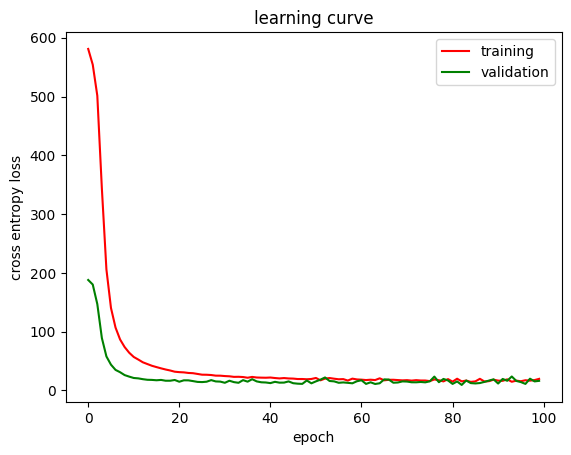



err_train: 19.769410132464746
err_valid: 16.39624459362258


In [58]:
def main():
    H = 3
    para_per_sample = 4
    # Setup list to help graph later
    epoch = []
    err_valid = []
    err_train = []

    # Initialize weights
    W1 = np.full((H, para_per_sample + 1), 1 / 5)  # 785 features so num of columns is 786
    W2 = np.full((H, H + 1), 1 / 5)
    W3 = np.full((1, H + 1), 1 / 5)

    for i in range(100): # epoch
        epoch.append(i)

        # SGD shaffle rows each time
        temp_arr = np.c_[X_train, t_train] # This concatenate array along the column axis
        np.random.shuffle(temp_arr)
        X = temp_arr[:, :-1]
        t = temp_arr[:, -1]

        y_pred = [] # output
        for j in range(len(X_train)): # iterate through every sample
            # update the weights each iteration
            Ws = [W1, W2, W3]
            y, Ws = neural_net_GD(X[j, :], t[j], Ws)
            W1, W2, W3 = Ws
            y_pred.append(y)
        y_pred = np.array(y_pred) # py list to np array
        
        # training cross entropy
        ce_loss_train = l_ce(t, y_pred)
        err_train.append(ce_loss_train)
        
        # validation cross entropy
        y_valid = []
        for j in range(len(X_valid)):  # iterate through every sample
            # use trained weights each iteration
            Ws = [W1, W2, W3]
            y, _WS = neural_net_GD(X_valid[j, :], t_valid[j], Ws)
            y_valid.append(y)
        y_valid = np.array(y_valid)
        ce_loss_valid = l_ce(t_valid, y_valid)
        err_valid.append(ce_loss_valid)

        # if output prob distribution > 0.5, classify it as class 1 else 0
        y_class = np.where(y_valid > 0.5, 1, 0)
        misclass_rate = 1 - accuracy_score(t_valid, y_class)

        #early stop
        # if i > 10 and ce_loss_valid > err_valid[-5]:
        #     break
        
    # plot learning curve
    plt.plot(epoch, err_train, color='red', label='training')
    plt.plot(epoch, err_valid, color='green', label='validation')
    plt.title('learning curve')
    plt.legend(loc='upper right')
    plt.xlabel('epoch')
    plt.ylabel('cross entropy loss')
    plt.show()
    print("\n")

    # calc validation, training error
    print("err_train: {0}".format(err_train[-1]))
    print("err_valid: {0}".format(err_valid[-1]))

        

if __name__ == '__main__':
    main()